Name:- Mandar Tarmale   19

  Chaitali Ranalkar  39

#Report on Ethereum (ETH-USD) Time Series Analysis and Forecasting

This report covers time series analysis and forecasting techniques used to analyze the Ethereum (ETH) price against the US Dollar (USD) using historical data over a five-year period from September 1, 2019, to August 31, 2024.

**Dataset Overview**

Time Range: September 1, 2019 – August 31, 2024

Total Entries: 1827 daily entries

Source: ETH-USD data is downloaded from Yahoo Finance

In [ ]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_squared_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM
from math import sqrt


[*********************100%***********************]  1 of 1 completed


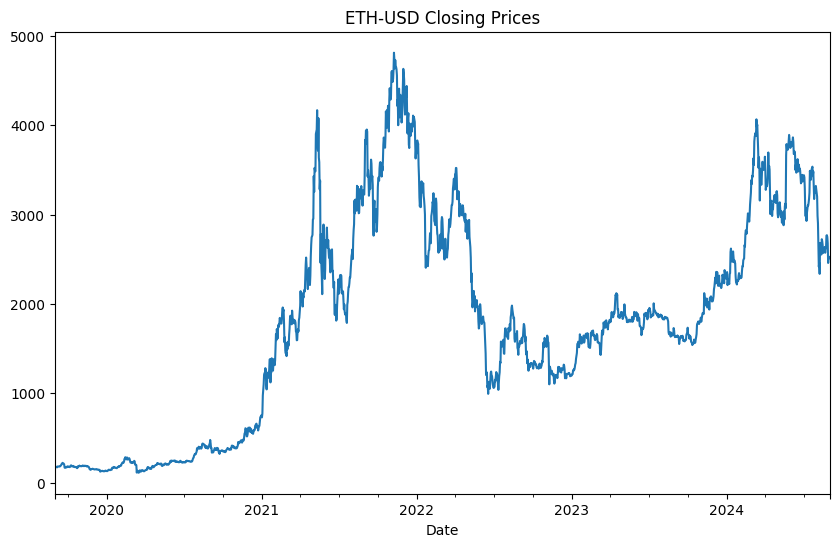

In [ ]:
# Downloading ETH-USD data from Yahoo Finance (5 years of daily data)
eth_data = yf.download('ETH-USD', start='2019-09-01', end='2024-09-01')

# Plot the closing price
eth_data['Close'].plot(figsize=(10,6), title="ETH-USD Closing Prices")
plt.show()


In [ ]:
print("Basic Information:")
print(eth_data.info())

# Display summary statistics
print("\nSummary Statistics:")
print(eth_data.describe())

# Display the first few rows of the data
print("\nFirst Few Rows:")
print(eth_data.head())

# Display the last few rows of the data
print("\nLast Few Rows:")
print(eth_data.tail())

Basic Information:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1827 entries, 2019-09-01 to 2024-08-31
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Open       1827 non-null   float64
 1   High       1827 non-null   float64
 2   Low        1827 non-null   float64
 3   Close      1827 non-null   float64
 4   Adj Close  1827 non-null   float64
 5   Volume     1827 non-null   int64  
dtypes: float64(5), int64(1)
memory usage: 99.9 KB
None

Summary Statistics:
              Open         High          Low        Close    Adj Close  \
count  1827.000000  1827.000000  1827.000000  1827.000000  1827.000000   
mean   1796.342484  1844.542674  1743.445709  1797.416831  1797.416831   
std    1193.202425  1225.477831  1155.900132  1192.319134  1192.319134   
min     110.406784   116.021622    95.184303   110.605873   110.605873   
25%     568.978760   584.932739   550.524658   570.020416   570.020416   
50%    1781.3500

In [ ]:
pip install yfinance

**Stationarity Test (ADF Test)**

In [ ]:
from statsmodels.tsa.stattools import adfuller

In [ ]:
# ADF Test for Stationarity
def adf_test(series):
    result = adfuller(series, autolag='AIC')
    print(f'ADF Statistic: {result[0]}')
    print(f'p-value: {result[1]}')
    return result[1]  # Return p-value

adf_test(eth_data['Close'])


ADF Statistic: -1.8907233485645583
p-value: 0.3364376458756839


0.3364376458756839

**First Order Differencing**

In [ ]:
# Differencing the data to make it stationary
eth_data['Close_diff'] = eth_data['Close'].diff().dropna()

# ADF test after differencing
adf_test(eth_data['Close_diff'].dropna())

ADF Statistic: -10.6878535738119
p-value: 3.7924358276185026e-19


3.7924358276185026e-19

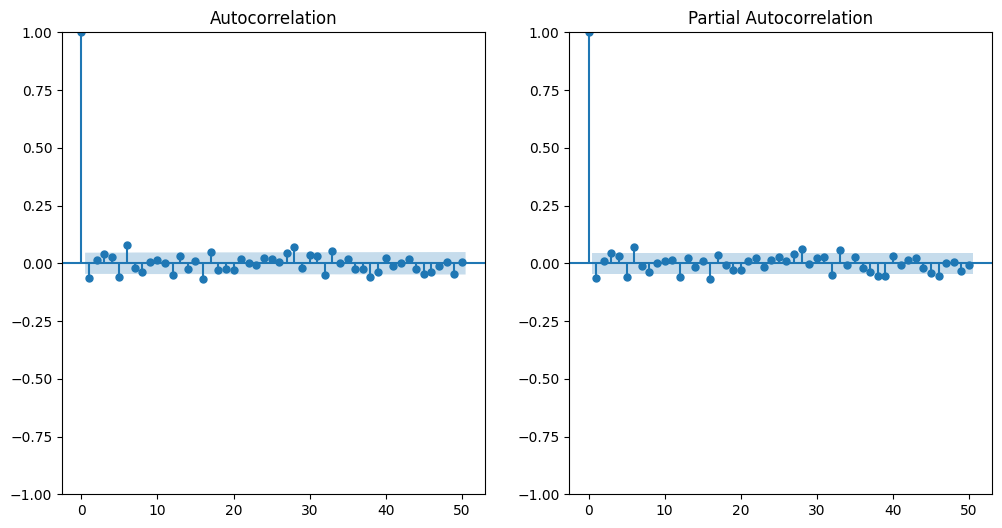

In [ ]:
# ACF and PACF plots for differenced data
plt.figure(figsize=(12,6))
plt.subplot(121)
plot_acf(eth_data['Close_diff'].dropna(), lags=50, ax=plt.gca())
plt.subplot(122)
plot_pacf(eth_data['Close_diff'].dropna(), lags=50, ax=plt.gca())
plt.show()

Here , the ACF and PACF plot gives the lag values of p=1 and q=1 rescepectively.

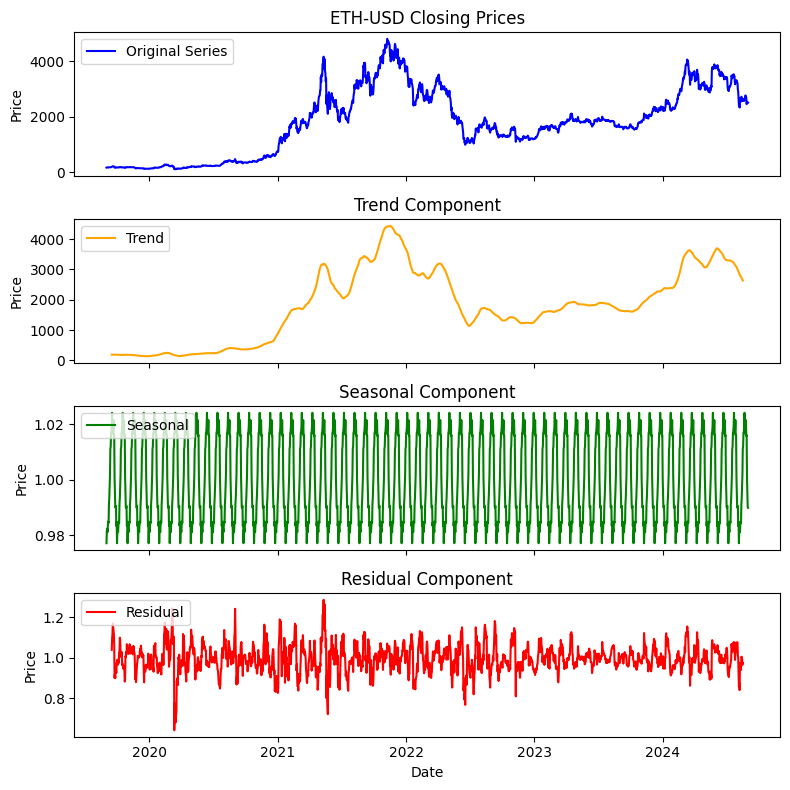

In [ ]:
# Perform seasonal decomposition with multiplicative model
result_mul = seasonal_decompose(eth_data['Close'], model='multiplicative', period=30)

# Plot the decomposition results
fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(8, 8), sharex=True)

# Original Series
ax1.plot(eth_data.index, eth_data['Close'], label='Original Series', color='blue')
ax1.set_title('ETH-USD Closing Prices')
ax1.set_ylabel('Price')
ax1.legend(loc='upper left')

# Trend Component
ax2.plot(result_mul.trend.index, result_mul.trend, label='Trend', color='orange')
ax2.set_title('Trend Component')
ax2.set_ylabel('Price')
ax2.legend(loc='upper left')

# Seasonal Component
ax3.plot(result_mul.seasonal.index, result_mul.seasonal, label='Seasonal', color='green')
ax3.set_title('Seasonal Component')
ax3.set_ylabel('Price')
ax3.legend(loc='upper left')

# Residual Component
ax4.plot(result_mul.resid.index, result_mul.resid, label='Residual', color='red')
ax4.set_title('Residual Component')
ax4.set_xlabel('Date')
ax4.set_ylabel('Price')
ax4.legend(loc='upper left')

# Improve layout
plt.tight_layout()
plt.show()

ethereum's price has a clear upward trend until 2021, followed by corrections but retaining a volatile nature.
Seasonality is present but does not have a huge influence on the price, while irregular residual components are more prominent during periods of high volatility.
The decomposition provides a good way to separate the underlying long-term movement (trend) from recurring short-term fluctuations (seasonality) and the noise (residual).

Here, We have split in the data into the ratio of 70:30.

In [ ]:
# Splitting the data into training and testing sets
train_size = int(len(eth_data) * 0.7)
train, test = eth_data['Close'][:train_size], eth_data['Close'][train_size:]


In [ ]:
!pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 14.1 MB/s eta 0:00:00


**Log Differnecing**

In [ ]:
import numpy as np
eth_data['Log_Close'] = np.log(eth_data['Close'])
eth_data['Log_Close_diff'] = eth_data['Log_Close'].diff().dropna()

# ADF test after differencing
adf_test(eth_data['Log_Close_diff'].dropna())

ADF Statistic: -12.945873207441338
p-value: 3.4568055791520535e-24


3.4568055791520535e-24

Since the p-value is less than 0.05. Hence, the time series is stationary.

**1. ARIMA (AutoRegressive Integrated Moving Average)**

In [ ]:
import numpy as np

# Assuming `train` is your time series data
train_log = np.log(train)

from pmdarima import auto_arima

# Automatically find the best SARIMA model for the log-transformed data
auto_model = auto_arima(train_log, seasonal=True, m=12, trace=True)
print(auto_model.summary())

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[12] intercept   : AIC=-4058.810, Time=21.31 sec
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=-4057.087, Time=0.75 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=-4058.428, Time=7.66 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=-4057.914, Time=3.39 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=-4057.429, Time=0.17 sec
 ARIMA(2,1,2)(0,0,1)[12] intercept   : AIC=-4060.703, Time=13.94 sec
 ARIMA(2,1,2)(0,0,0)[12] intercept   : AIC=-4062.220, Time=1.10 sec
 ARIMA(2,1,2)(1,0,0)[12] intercept   : AIC=-4060.704, Time=9.14 sec
 ARIMA(1,1,2)(0,0,0)[12] intercept   : AIC=-4064.364, Time=2.02 sec
 ARIMA(1,1,2)(1,0,0)[12] intercept   : AIC=-4062.368, Time=4.54 sec
 ARIMA(1,1,2)(0,0,1)[12] intercept   : AIC=-4062.367, Time=8.03 sec
 ARIMA(1,1,2)(1,0,1)[12] intercept   : AIC=-4060.475, Time=5.58 sec
 ARIMA(0,1,2)(0,0,0)[12] intercept   : AIC=-4061.375, Time=0.92 sec
 ARIMA(1,1,1)(0,0,0)[12] intercept   : AIC=-4066.341, Time=1.11 sec
 AR

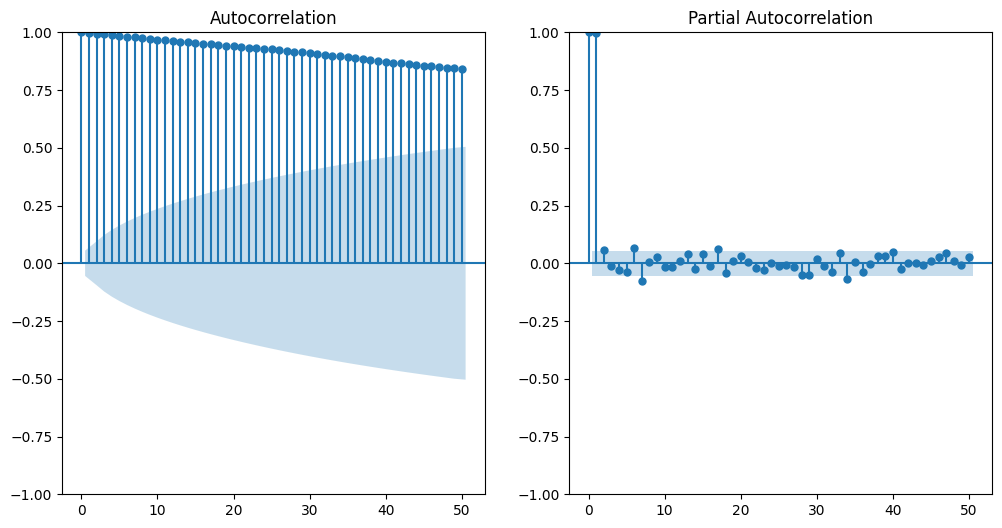

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

# Plot ACF and PACF
plt.figure(figsize=(12,6))
plt.subplot(121)
plot_acf(train, lags=50, ax=plt.gca())
plt.subplot(122)
plot_pacf(train, lags=50, ax=plt.gca())
plt.show()

##### Interpretation of ACF and PACF Plots:

###### **Autocorrelation Function (ACF)**:
- **High autocorrelation at multiple lags**:
  - The ACF plot shows high positive autocorrelation for many lags, which indicates a strong trend component in the time series. This suggests that the data is **non-stationary** and needs to be differenced to remove the trend.
  - The fact that the autocorrelation does not drop off quickly suggests that the series has a **long memory** or persistent trend.

- **Seasonality**:
  - There is no clear seasonal pattern visible in the ACF plot. Normally, if there were seasonality, you would expect significant spikes at multiples of the seasonal period (e.g., every 12 lags for monthly data).

###### **Partial Autocorrelation Function (PACF)**:
- **Significant lag at 1**:
  - The PACF shows a significant spike at lag 1 and then quickly drops off. This is indicative of a potential **AR(1)** process, meaning that the time series depends strongly on the value from one lag prior.
  
- **Lack of seasonality**:
  - There are no significant spikes beyond lag 1, which also suggests that there is no seasonality in the data. If there were, we would see additional significant spikes at higher lags (e.g., at multiples of 12 for seasonal data).




**2. SARIMA (Seasonal ARIMA)**

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Fit SARIMA model with no seasonal components
sarima_model = SARIMAX(train, order=(1, 1, 2), seasonal_order=(0, 0, 0, 12))
sarima_result = sarima_model.fit(disp=False)
print(sarima_result.summary())

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                 1278
Model:               SARIMAX(1, 1, 2)   Log Likelihood               -7608.115
Date:                Sat, 21 Sep 2024   AIC                          15224.230
Time:                        17:51:29   BIC                          15244.839
Sample:                    09-01-2019   HQIC                         15231.969
                         - 03-01-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.8107      0.136     -5.946      0.000      -1.078      -0.543
ma.L1          0.7441      0.140      5.314      0.000       0.470       1.019
ma.L2         -0.0292      0.023     -1.285      0.1

Forecasted Values:
 2023-03-02    1659.474496
2023-03-03    1661.040482
2023-03-04    1659.770950
2023-03-05    1660.800150
2023-03-06    1659.965785
2023-03-07    1660.642198
2023-03-08    1660.093835
2023-03-09    1660.538389
2023-03-10    1660.177993
2023-03-11    1660.470163
2023-03-12    1660.233303
2023-03-13    1660.425324
Freq: D, Name: predicted_mean, dtype: float64

Confidence Intervals:
             lower Close  upper Close
2023-03-02  1476.052964  1842.896028
2023-03-03  1410.134773  1911.946191
2023-03-04  1353.437747  1966.104152
2023-03-05  1309.452095  2012.148204
2023-03-06  1267.426310  2052.505260
2023-03-07  1231.821155  2089.463241
2023-03-08  1197.093768  2123.093903
2023-03-09  1166.273582  2154.803196
2023-03-10  1136.084288  2184.271697
2023-03-11  1108.485218  2212.455108
2023-03-12  1081.445829  2239.020776
2023-03-13  1056.220286  2264.630361


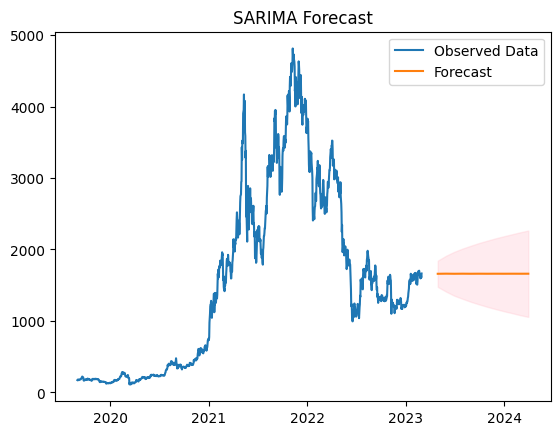

In [ ]:
# Number of periods to forecast (e.g., forecasting for the next 12 steps)
n_steps = 12

# Get the forecast for n_steps ahead
forecast = sarima_result.get_forecast(steps=n_steps)

# Extract the predicted mean (forecasted values)
forecast_values = forecast.predicted_mean

# Get the confidence intervals for the forecast
confidence_intervals = forecast.conf_int()

# Print forecast values and confidence intervals
print("Forecasted Values:\n", forecast_values)
print("\nConfidence Intervals:\n", confidence_intervals)

# If you want to visualize the forecast:
forecast_index = pd.date_range(start=train.index[-1], periods=n_steps + 1, freq='M')[1:]  # Assuming monthly frequency
plt.plot(train.index, train, label='Observed Data')
plt.plot(forecast_index, forecast_values, label='Forecast')
plt.fill_between(forecast_index,
                 confidence_intervals.iloc[:, 0],
                 confidence_intervals.iloc[:, 1],
                 color='pink', alpha=0.3)
plt.title("SARIMA Forecast")
plt.legend()
plt.show()

In [ ]:
# Make predictions on the test data
predictions = sarima_result.get_prediction(start=len(train), end=len(eth_data) - 1)
predicted_values = predictions.predicted_mean

# Calculate RMSE
sarima_rmse = sqrt(mean_squared_error(test, predicted_values))
print(f"RMSE: {sarima_rmse}")


RMSE: 1031.440781744152


**3. Holt's Winter Method**

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


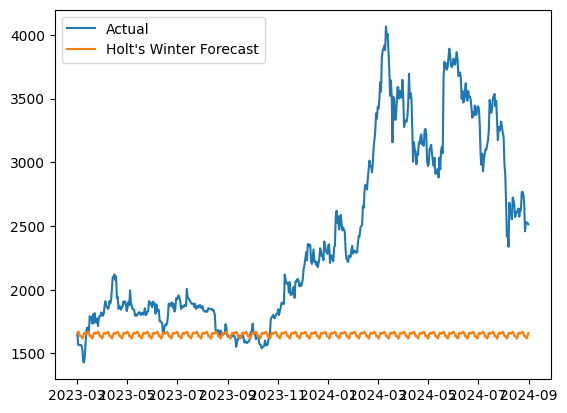

Holt's Winter RMSE: 1040.0821993236498


In [ ]:
# Holt's Winter Exponential Smoothing
hw_model = ExponentialSmoothing(train, seasonal='mul', seasonal_periods=12)
hw_result = hw_model.fit()

# Forecasting
hw_forecast = hw_result.forecast(len(test))
plt.plot(test.index, test, label='Actual')
plt.plot(test.index, hw_forecast, label="Holt's Winter Forecast")
plt.legend()
plt.show()

# Holt's Winter RMSE
hw_rmse = sqrt(mean_squared_error(test, hw_forecast))
print(f'Holt\'s Winter RMSE: {hw_rmse}')


**4. LSTM (Long Short-Term Memory) Neural Network**

Epoch 1/10


/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


39/39 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - loss: 0.0600
Epoch 2/10
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0025
Epoch 3/10
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0023
Epoch 4/10
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0019
Epoch 5/10
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0021
Epoch 6/10
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0020
Epoch 7/10
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0014
Epoch 8/10
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0015
Epoch 9/10
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0017
Epoch 10/10
39/39 ━━━━━━━━━━━━━━━━━━━━ 3s 75ms/step - loss: 0.0014
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 82ms/step
LSTM RMSE: 135.81706560150295


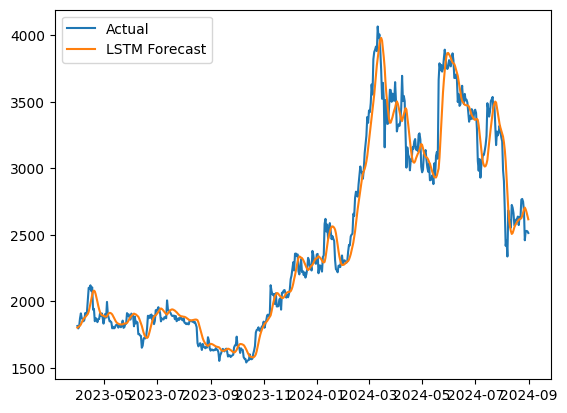

In [ ]:
# LSTM Model Preparation
train_data = train.values.reshape(-1, 1)
test_data = test.values.reshape(-1, 1)

# Scale data
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler.fit_transform(train_data)
test_scaled = scaler.transform(test_data)

# Create sequences for LSTM
def create_dataset(dataset, look_back=1):
    X, Y = [], []
    for i in range(len(dataset)-look_back):
        X.append(dataset[i:(i+look_back), 0])
        Y.append(dataset[i + look_back, 0])
    return np.array(X), np.array(Y)

look_back = 30
X_train, y_train = create_dataset(train_scaled, look_back)
X_test, y_test = create_dataset(test_scaled, look_back)

X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

# LSTM Model
lstm_model = Sequential()
lstm_model.add(LSTM(50, return_sequences=True, input_shape=(X_train.shape[1], 1)))
lstm_model.add(LSTM(50))
lstm_model.add(Dense(1))

lstm_model.compile(optimizer='adam', loss='mean_squared_error')
lstm_model.fit(X_train, y_train, epochs=10, batch_size=32)

# Predictions
lstm_predictions = lstm_model.predict(X_test)
lstm_predictions = scaler.inverse_transform(lstm_predictions)

# LSTM RMSE
lstm_rmse = sqrt(mean_squared_error(test[look_back:], lstm_predictions))
print(f'LSTM RMSE: {lstm_rmse}')

# Plotting
plt.plot(test.index[look_back:], test[look_back:], label='Actual')
plt.plot(test.index[look_back:], lstm_predictions, label='LSTM Forecast')
plt.legend()
plt.show()

**5. Prophet Model**

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpb_wbiixi/gbp0cu3t.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpb_wbiixi/txzdmuk2.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.10/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=60307', 'data', 'file=/tmp/tmpb_wbiixi/gbp0cu3t.json', 'init=/tmp/tmpb_wbiixi/txzdmuk2.json', 'output', 'file=/tmp/tmpb_wbiixi/prophet_model__0sw3w_/prophet_model-20240921175203.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
17:52:03 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
17:52:04 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing
/usr/local/lib/python3.10/dist-packages/prophet/plot.py:72: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in 

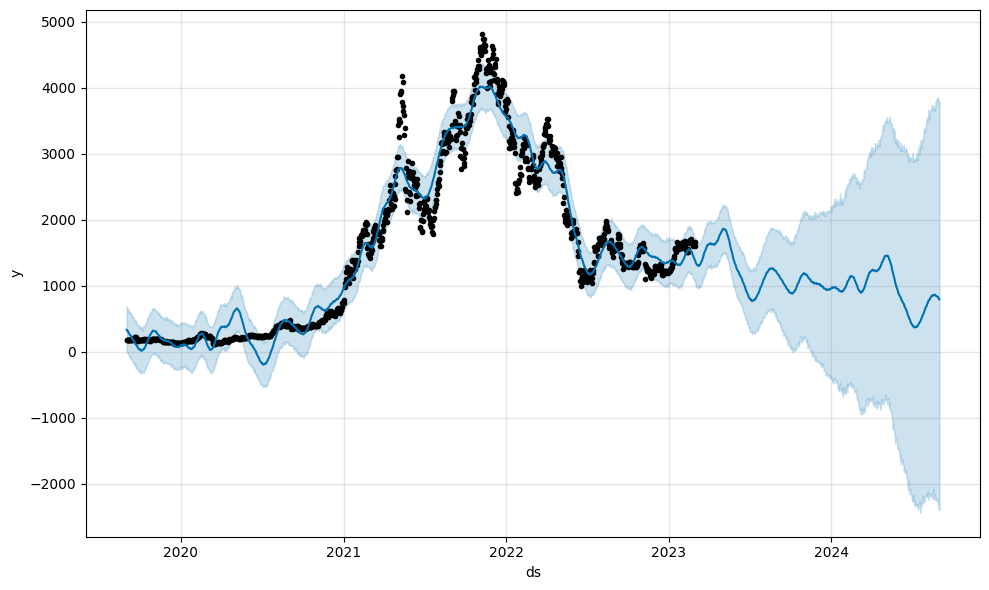

/usr/local/lib/python3.10/dist-packages/prophet/plot.py:228: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result
  fcst_t = fcst['ds'].dt.to_pydatetime()
/usr/local/lib/python3.10/dist-packages/prophet/plot.py:351: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result
  df_y['ds'].dt.to_pydatetime(), seas[name], ls='-', c='#0072B2')
/usr/local/lib/python3.10/dist-packages/prophet/plot.py:354: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` o

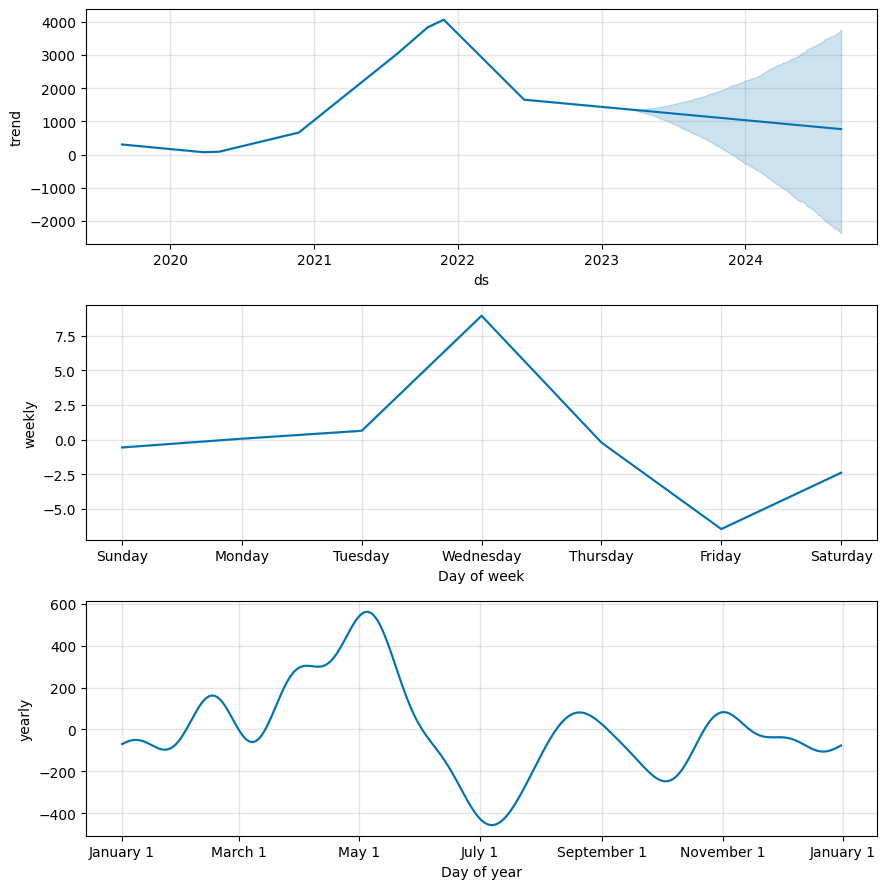

Prophet RMSE: 1594.1342987048984


In [ ]:
!pip install prophet

from prophet import Prophet

# Prepare data for Prophet
prophet_data = eth_data[['Close']].reset_index()
prophet_data.columns = ['ds', 'y']

# Create and fit the Prophet model
model = Prophet()
model.fit(prophet_data[:train_size])

# Create future dataframe for predictions
future = model.make_future_dataframe(periods=len(test), freq='D')

# Make predictions
forecast = model.predict(future)

# Plot the forecast
fig = model.plot(forecast)
plt.show()

# Plot the forecast components
fig = model.plot_components(forecast)
plt.show()

# Evaluate the model
from sklearn.metrics import mean_squared_error
from math import sqrt

# Extract the predicted values for the test set
predictions = forecast['yhat'][-len(test):]

# Calculate RMSE
prophet_rmse = sqrt(mean_squared_error(test, predictions))
print(f'Prophet RMSE: {prophet_rmse}')


In [ ]:
# RMSE Comparison
print(f'SARIMA RMSE: {sarima_rmse}')
print(f'Holt\'s Winter RMSE: {hw_rmse}')
print(f'LSTM RMSE: {lstm_rmse}')
print(f'Prophet RMSE: {prophet_rmse}')

SARIMA RMSE: 1031.440781744152
Holt's Winter RMSE: 1040.0821993236498
LSTM RMSE: 135.81706560150295
Prophet RMSE: 1594.1342987048984


### Model Evaluation Based on RMSE Values

Final RMSE values for each model evaluated on the held-out test set:

| Model | RMSE |
|---|---|
| **LSTM** | **135.82** |
| SARIMA | 1031.44 |
| Holt's Winter | 1040.08 |
| Prophet | 1594.13 |

#### Conclusion

- **LSTM** has the lowest RMSE (135.82) by a wide margin — roughly 7.6x lower error than the next best model. As a neural network it captures the complex, non-linear patterns in Ethereum's price data far more effectively than the classical approaches.

- **SARIMA (1031.44)** and **Holt's Winter (1040.08)** finish close together in the middle. Both track the broad level of the series but fail to anticipate its sharp swings.

- **Prophet** is the weakest of the four at 1594.13. Its additive trend-plus-seasonality structure is a poor fit here: the seasonal decomposition showed only a weak seasonal component, while volatility dominates the series.

#### Note on ARIMA

`auto_arima` was used to identify the best ARIMA order on the log-transformed training series, selecting ARIMA(1,1,1). No separate ARIMA forecast was generated against the test set, so ARIMA carries no RMSE in the comparison above — four models were scored, not five.

#### Recommendation

Based on the RMSE values, **LSTM** is the best-performing model for forecasting Ethereum prices. Where interpretability or lower computational cost matters more than raw accuracy, **SARIMA** is the better fallback — it is both simpler and more accurate than Prophet on this data.

*Note: the LSTM is trained without a fixed random seed, so its RMSE varies slightly between runs.*